* Import Libraries

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.utils.class_weight import compute_class_weight
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import f_classif, chi2
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,StandardScaler, power_transform
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

* Read Dataset

In [2]:
DATA_PATH = os.path.join(os.getcwd(), '..', 'dataset', 'Churn_Modelling.csv')
df = pd.read_csv(DATA_PATH)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Adjust Column Names
df.columns = df.columns.str.strip().str.replace(' ', '_')

In [4]:
# Drop First 3 Features
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [6]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


* EDA

In [7]:
df.isna().sum(axis=0)

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [8]:
# Geography
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [9]:
# Gender
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [10]:
# Target (Imbalanced Data Type, So We Will Use F_1 Score To Evaluate)
df['Exited'].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [11]:
df.dtypes

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [12]:
# Tenure (Client With Bank For n Years)
df['Tenure'].unique()

array([ 2,  1,  8,  7,  4,  6,  3, 10,  5,  9,  0])

* Data Viz & Handling Outliers

* -- UniVariate Viz

array([[<Axes: title={'center': 'CreditScore'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Tenure'}>],
       [<Axes: title={'center': 'Balance'}>,
        <Axes: title={'center': 'NumOfProducts'}>,
        <Axes: title={'center': 'HasCrCard'}>],
       [<Axes: title={'center': 'IsActiveMember'}>,
        <Axes: title={'center': 'EstimatedSalary'}>,
        <Axes: title={'center': 'Exited'}>]], dtype=object)

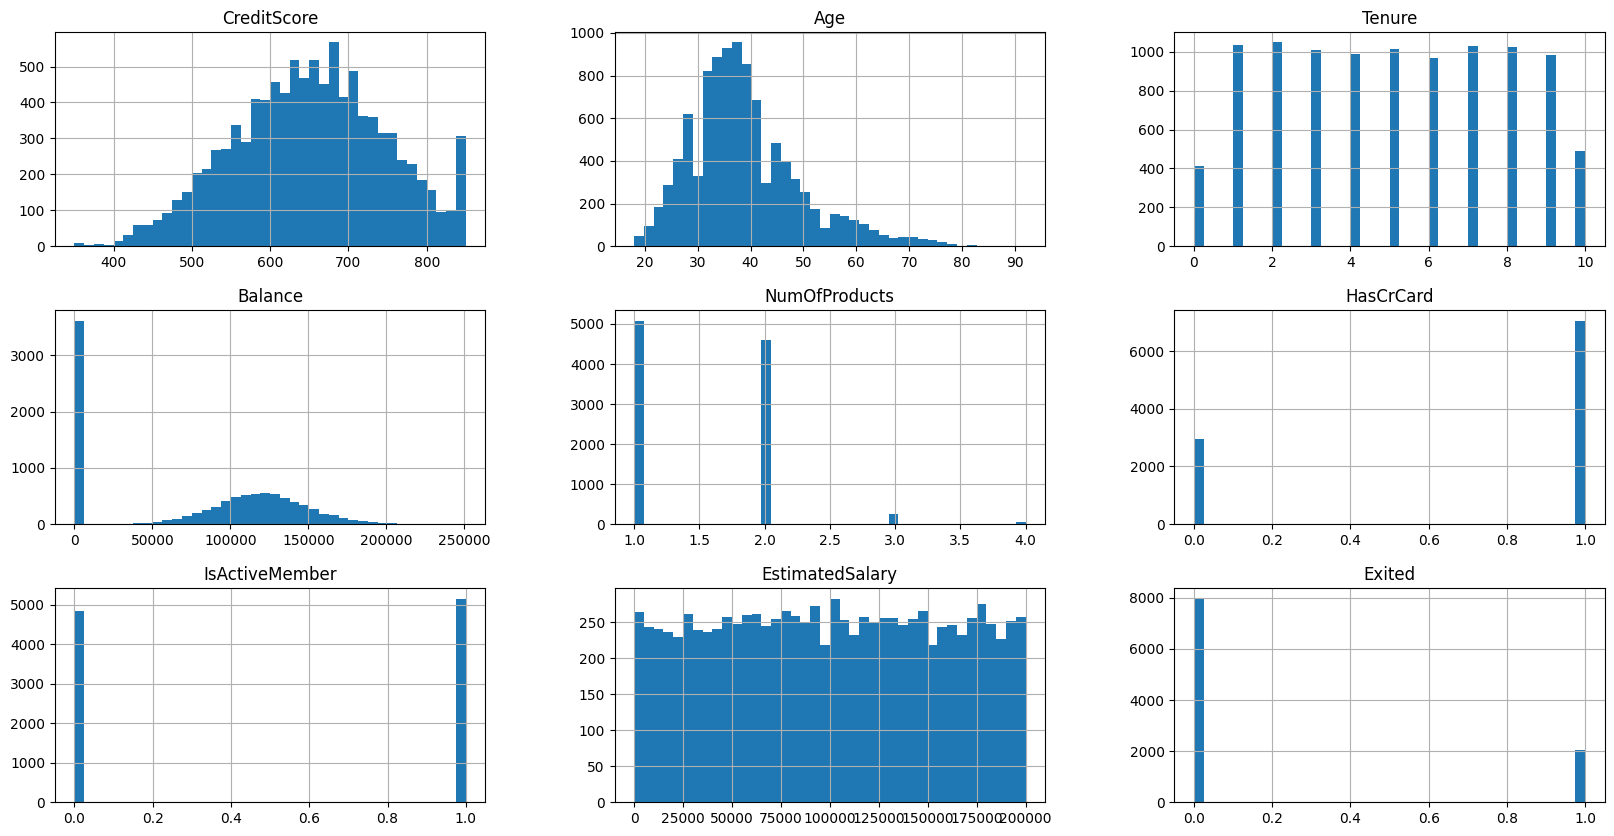

In [13]:
# Numerical Cols
df.hist(bins=40, figsize=(20, 10))

* '-- Credit Score Is litle Skeweness'
* '-- Age Is More Skeweness (Outlires)'

In [14]:
# power_transform()
# Our Data Has -ve , So We Can't Use it

In [15]:
# Drop > 80 (Custom Threshold)
df.drop(index=df[df['Age'] > 80 ].index.tolist(), axis=0, inplace=True)

<Axes: ylabel='Age'>

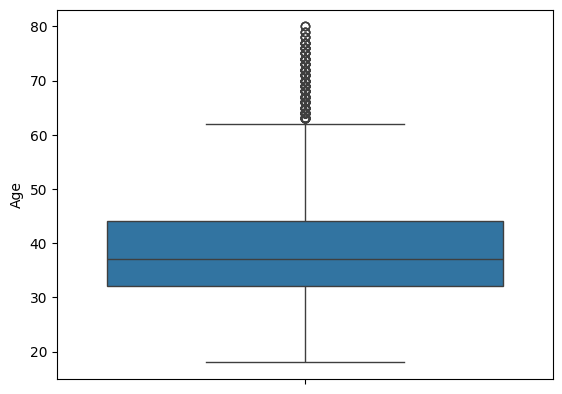

In [16]:
sns.boxplot(data=df, y='Age')

<Axes: xlabel='Age', ylabel='Count'>

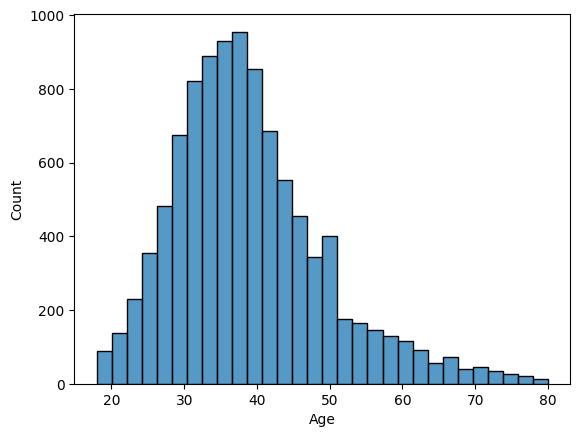

In [17]:
sns.histplot(data=df, x='Age', bins=30)

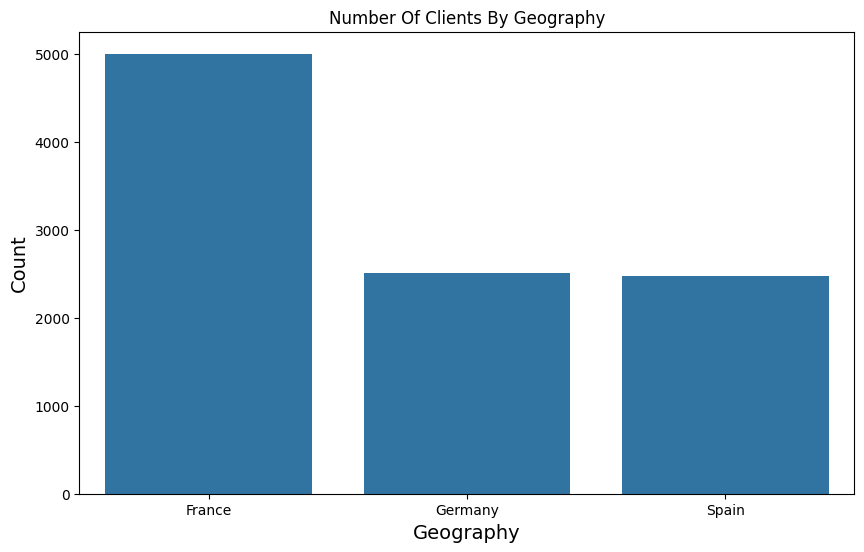

In [18]:
# Countplot For Geography
plt.figure(figsize=(10, 6))
plt.title("Number Of Clients By Geography")
sns.countplot(data=df, x='Geography', order=df['Geography'].value_counts().index.tolist()) 
plt.xlabel('Geography', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

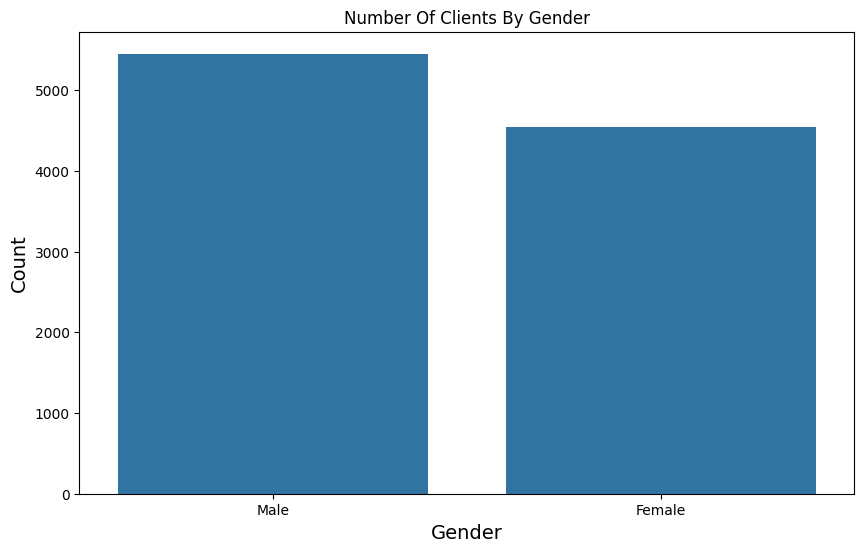

In [19]:
# Countplot For Gender
plt.figure(figsize=(10, 6))
plt.title("Number Of Clients By Gender")
sns.countplot(data=df, x='Gender', order=df['Gender'].value_counts().index.tolist()) 
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

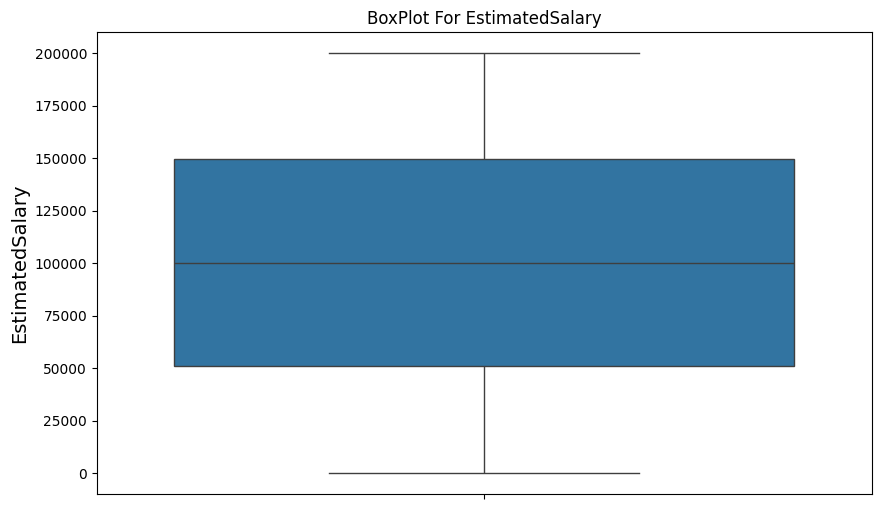

In [20]:
# Boxplot For (EstimatedSalary)
plt.figure(figsize=(10, 6))
plt.title("BoxPlot For EstimatedSalary")
sns.boxplot(data=df, y='EstimatedSalary') 
plt.ylabel('EstimatedSalary', fontsize=14)
plt.show()

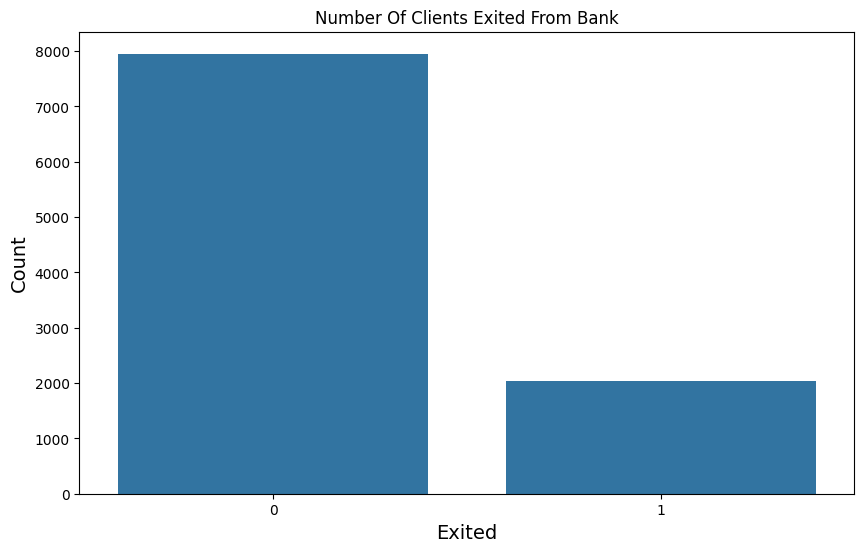

In [21]:
# Countplot For Exited (Target)
plt.figure(figsize=(10, 6))
plt.title("Number Of Clients Exited From Bank")
sns.countplot(data=df, x='Exited', order=df['Exited'].value_counts().index.tolist()) 
plt.xlabel('Exited', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

* -- BiVariate Viz

In [22]:
# Average Salary For Each Gender
df[['Gender','EstimatedSalary']].groupby('Gender')['EstimatedSalary'].mean()

Gender
Female    100575.998277
Male       99671.901194
Name: EstimatedSalary, dtype: float64

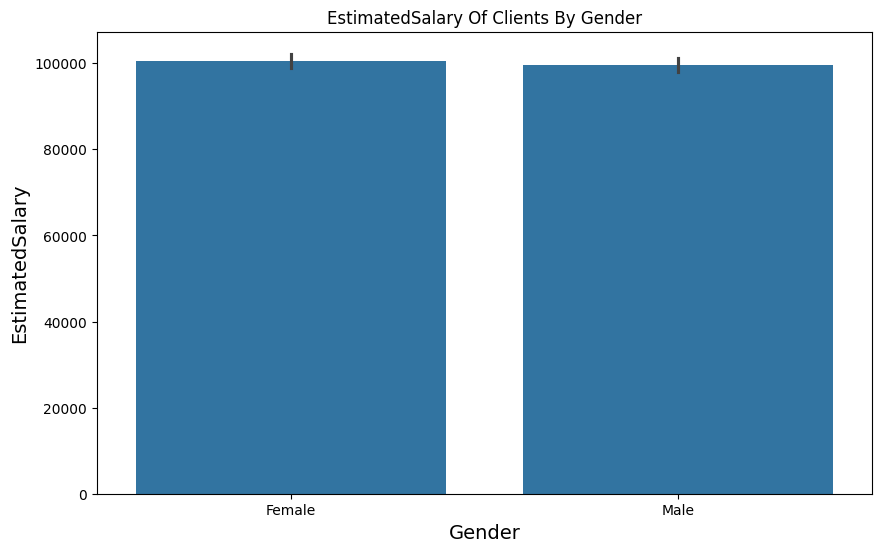

In [23]:
# BarPlot For Exited (Target)
plt.figure(figsize=(10, 6))
plt.title("EstimatedSalary Of Clients By Gender")
sns.barplot(data=df, y='EstimatedSalary',x='Gender', estimator='mean') 
plt.xlabel('Gender', fontsize=14)
plt.ylabel('EstimatedSalary', fontsize=14)
plt.show()

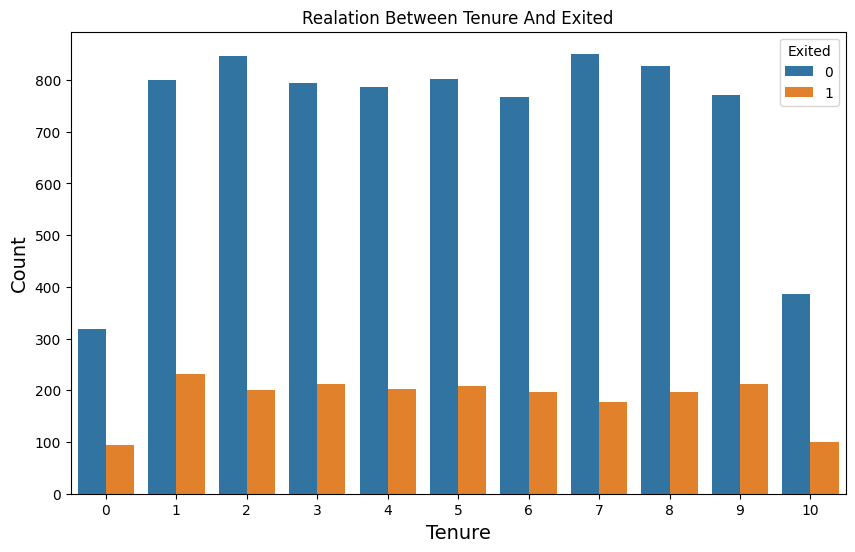

In [24]:
# Realation Between Tenure And Exited
plt.figure(figsize=(10, 6))
plt.title("Realation Between Tenure And Exited")
sns.countplot(data=df, x='Tenure', hue='Exited') 
plt.xlabel('Tenure', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

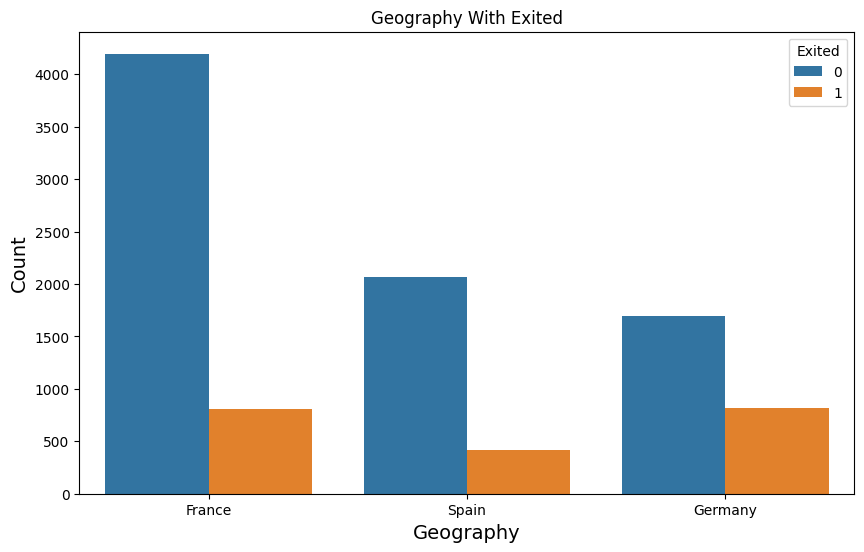

In [25]:
# Geography With Exited
plt.figure(figsize=(10, 6))
plt.title("Geography With Exited")
sns.countplot(data=df, x='Geography', hue='Exited') 
plt.xlabel('Geography', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

* Split To Train & Test

In [26]:
# To Features And Target
X = df.drop(columns='Exited', axis=1)
y = df['Exited']

# To Train And Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, random_state=45, shuffle=True, stratify=y)

# Check Shapes
print('X_train.shape \t', X_train.shape)
print('X_test.shape \t', X_test.shape)
print('***'*10)
print('y_train.shape \t', y_train.shape)
print('y_test.shape \t', y_test.shape)


X_train.shape 	 (7990, 10)
X_test.shape 	 (1998, 10)
******************************
y_train.shape 	 (7990,)
y_test.shape 	 (1998,)


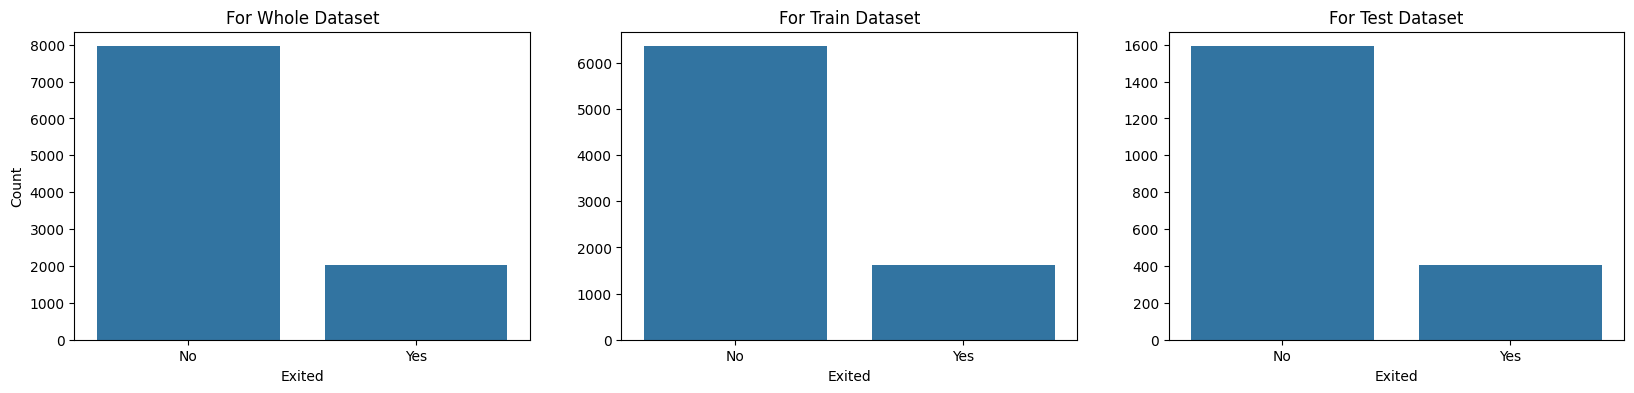

In [27]:
# Plotting To Check Target
fig, ax = plt.subplots(1, 3, figsize=(20, 4))

# Whole Dataset
plt.sca(ax[0])
sns.countplot(x=y)
plt.title('For Whole Dataset')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])

# Train
plt.sca(ax[1])
sns.countplot(x=y_train)
plt.title('For Train Dataset')
plt.ylabel('')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])

# Test
plt.sca(ax[2])
sns.countplot(x=y_test)
plt.title('For Test Dataset')
plt.ylabel('')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])

plt.show()

* Feature Selectin & Preprocessing

In [28]:
# Slice Cols
num_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']
categ_cols = ['Geography', 'Gender']

ready_cols =  list(set(X_train.columns.tolist()) - set(num_cols) - set(categ_cols))

In [29]:
# Numerical cols (num cols) & Target cols (Discrete) -->  ANOVA
_ , p_val = f_classif(X=X_train[num_cols], y=y_train)
p_val   # p_val < .05 , So Important Feature (Reject H0 {That Say No Assocation})

array([9.12989970e-002, 1.15359217e-149, 3.56368021e-025, 6.16127881e-001])

In [30]:
# Categorical cols (categ cols) & Target cols (Discrete) -->  CHI-Square (Need Encoding Before Using)
_ , p_val = chi2(X=OrdinalEncoder().fit_transform(X_train[categ_cols]), y=y_train)  
p_val    # p_val < .05 , So Important Feature (Reject H0 {That Say No Assocation})

array([1.56448286e-03, 5.13986341e-10])

* Pipeline

In [31]:
# Pipeline

# Numerical: num_cols --> Imputing Using Median, And StandardScaler
# Categorical: categ_cols --> Imputing Using Mode, And OHE
# Ready_Cols: --> Imputing Using Mode

# For Numerical
num_pipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='median')),
    ('Scaler', StandardScaler())
])


# For Categorical
categ_pipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='most_frequent')),
    ('Scaler', OneHotEncoder(sparse_output=False, drop='first'))
])


# For Ready Cols
ready_pipeline = Pipeline([
    ('Imputer', SimpleImputer(strategy='most_frequent')),
])


# Combine All
preprocessor = ColumnTransformer(transformers = [
    ('numerical', num_pipeline, num_cols),
    ('categorical', categ_pipeline, categ_cols),
    ('ready', ready_pipeline, ready_cols)
])


# Apply To Train And Test
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

In [32]:
# Check Train
X_train_final.shape, y_train.shape

# Because Of OHE We Has Now 11 Features Not 10

((7990, 11), (7990,))

In [33]:
# Check Test
X_test_final.shape, y_test.shape

((1998, 11), (1998,))

* Deal With Imbalanced Data

In [34]:
# 1.Using Class Weight Param In Model
vals_count = 1 - (np.bincount(y_train) / len(y_train))
vals_count = vals_count / sum(vals_count)

dict_weights = {}
for i in range(2):
        dict_weights[i] = vals_count[i]
        
# In Model
dict_weights

{0: np.float64(0.20387984981226537), 1: np.float64(0.7961201501877346)}

* Random Under Sampling

In [35]:
# 2. Using Smote For OverSampling
over = SMOTE(k_neighbors=5, sampling_strategy=0.7)  # Work only On Numerical (Preprocessed) Data 
X_train_final_resampled, y_train_final_resampled = over.fit_resample(X_train_final, y_train)

In [36]:
y_train_final_resampled.value_counts()[1] / y_train_final_resampled.value_counts()[0]

np.float64(0.699889954409684)

In [37]:
# Create Folder For The Models
MODELS_FOLDER_PATH = os.path.join(os.getcwd(), '..', 'models')
os.makedirs(MODELS_FOLDER_PATH, exist_ok=True)

In [38]:
# Dump The Preprocessor
joblib.dump(preprocessor, os.path.join(MODELS_FOLDER_PATH, 'preprocessor.pkl'))

['c:\\Users\\eyad0\\Documents\\python\\Agoor\\churn_live\\notebooks\\..\\models\\preprocessor.pkl']

---

* Building Models

--- Let's Consider The Evaluation Metric To Be f1_Score

1. Using Logistic Regression

In [39]:
# 1. Using Logistic -- Without Considering The Imbalancing Data
log_clf = LogisticRegression(C=1.5)
log_clf.fit(X_train_final, y_train)

# Predict And Evaluate
y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

# Using f1_score
score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f"The f1_score Using Logistic Model For Training Dataset Is: {score_train_log}")
print(f"The f1_score Using Logistic Model For Testing Dataset Is: {score_test_log}")


The f1_score Using Logistic Model For Training Dataset Is: 0.3088838268792711
The f1_score Using Logistic Model For Testing Dataset Is: 0.375


In [40]:
# 1. Using Logistic -- With Considering The Imbalanced Data Using Class Weights
log_clf = LogisticRegression(C=1.5, class_weight=dict_weights)
log_clf.fit(X_train_final, y_train)

# Predict And Evaluate
y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

# Using f1_score
score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f"The f1_score Using Logistic Model For Training Dataset With class_weights Is: {score_train_log}")
print(f"The f1_score Using Logistic Model For Testing Dataset With class_weights Is: {score_test_log}")


The f1_score Using Logistic Model For Training Dataset With class_weights Is: 0.4981380065717415
The f1_score Using Logistic Model For Testing Dataset With class_weights Is: 0.499151103565365


In [41]:
# 3. Using Logistic -- With Considering The Imbalanced Data Using Oversampled Data (Smote)
log_clf = LogisticRegression(C=1.5)
log_clf.fit(X_train_final_resampled, y_train_final_resampled)

# Predict And Evaluate
y_pred_train_log = log_clf.predict(X_train_final)
y_pred_test_log = log_clf.predict(X_test_final)

# Using f1_score
score_train_log = f1_score(y_train, y_pred_train_log)
score_test_log = f1_score(y_test, y_pred_test_log)

print(f"The f1_score Using Logistic Model For Training Dataset With Smote Is: {score_train_log}")
print(f"The f1_score Using Logistic Model For Testing Dataset With Smote Is: {score_test_log}")


The f1_score Using Logistic Model For Training Dataset With Smote Is: 0.4982475060663252
The f1_score Using Logistic Model For Testing Dataset With Smote Is: 0.5078369905956113


<Axes: >

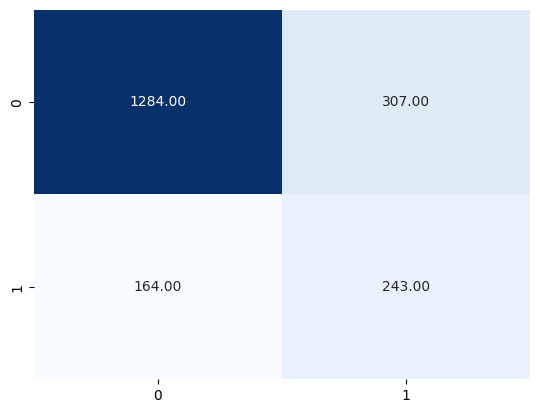

In [42]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_true=y_test, y_pred=y_pred_test_log), cmap='Blues', annot=True, cbar=False, fmt='.2f')

In [43]:
print(classification_report(y_true=y_test, y_pred=y_pred_test_log))

              precision    recall  f1-score   support

           0       0.89      0.81      0.85      1591
           1       0.44      0.60      0.51       407

    accuracy                           0.76      1998
   macro avg       0.66      0.70      0.68      1998
weighted avg       0.80      0.76      0.78      1998



* Random Forest

In [44]:
# Using RF -- With Class_weights
forest_clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=45, class_weight=dict_weights)
forest_clf.fit(X_train_final, y_train)

# Predict And Evaluate
y_pred_train_forest = forest_clf.predict(X_train_final)
y_pred_test_forest = forest_clf.predict(X_test_final)

# Using f1_score
score_train_forest = f1_score(y_train, y_pred_train_forest)
score_test_forest = f1_score(y_test, y_pred_test_forest)

print(f"The f1_score Using RF Model For Training Dataset With class_weights Is: {score_train_forest}")
print(f"The f1_score Using RF Model For Training Dataset With class_weights Is: {score_test_forest}")

The f1_score Using RF Model For Training Dataset With class_weights Is: 0.6001003512293026
The f1_score Using RF Model For Training Dataset With class_weights Is: 0.5734265734265734


In [45]:
# Using RF -- With Smote
forest_clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=45)
forest_clf.fit(X_train_final_resampled, y_train_final_resampled)

# Predict And Evaluate
y_pred_train_forest = forest_clf.predict(X_train_final)
y_pred_test_forest = forest_clf.predict(X_test_final)

# Using f1_score
score_train_forest = f1_score(y_train, y_pred_train_forest)
score_test_forest = f1_score(y_test, y_pred_test_forest)

print(f"The f1_score Using RF Model For Training Dataset With Smote Is: {score_train_forest}")
print(f"The f1_score Using RF Model For Training Dataset With Smote Is: {score_test_forest}")

The f1_score Using RF Model For Training Dataset With Smote Is: 0.6179664363277394
The f1_score Using RF Model For Training Dataset With Smote Is: 0.5899094437257438


* RF-Tuning

In [ ]:
forest_base_clf = RandomForestClassifier(n_estimators=150, max_depth=5, random_state=45, class_weight=dict_weights)

# Your Space TO Search
params_best_gid = {
    'n_estimators': np.arange(50, 400, 50),
    'max_depth': np.arange(2, 10, 2)
}

grid_search_forest = GridSearchCV(estimator=forest_base_clf, param_grid=params_best_gid,
                                  cv=5, n_jobs=-1, verbose=2, scoring='f1')
grid_search_forest.fit(X_train_final, y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,estimator,RandomForestC...ndom_state=45)
,param_grid,"{'max_depth': array([2, 4, 6, 8]), 'n_estimators': array([ 50, 1...50, 300, 350])}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,np.int64(200)


In [47]:
# The Best Score According To Your Scoring & The Best Combination Of What You Search In
grid_search_forest.best_score_, grid_search_forest.best_params_

(np.float64(0.615690320337744),
 {'max_depth': np.int64(8), 'n_estimators': np.int64(200)})

In [48]:
# The Forest After Tunning
forest_tuned = grid_search_forest.best_estimator_

# Predict And Evaluate
y_pred_train_forest_tuned = forest_tuned.predict(X_train_final)
y_pred_test_forest_tuned = forest_tuned.predict(X_test_final)

# Using f1_score
score_train_forest_tuned = f1_score(y_train, y_pred_train_forest_tuned)
score_test_forest_tuned = f1_score(y_test, y_pred_test_forest_tuned)

print(f"The f1_score Using Tuned RF Model For Training Dataset With class_weights Is: {score_train_forest_tuned}")
print(f"The f1_score Using Tuned RF Model For Testing Dataset With class_weights Is: {score_test_forest_tuned}")

The f1_score Using Tuned RF Model For Training Dataset With class_weights Is: 0.6796382570567279
The f1_score Using Tuned RF Model For Testing Dataset With class_weights Is: 0.6233766233766234


In [49]:
# Dump The Preprocessor
joblib.dump(forest_tuned, os.path.join(MODELS_FOLDER_PATH, 'forest_tuned.pkl'))

['c:\\Users\\eyad0\\Documents\\python\\Agoor\\churn_live\\notebooks\\..\\models\\forest_tuned.pkl']

In [50]:
forest_tuned.feature_importances_

array([0.04888902, 0.37467508, 0.09513631, 0.05182749, 0.05456509,
       0.00682789, 0.02164355, 0.24873647, 0.00628926, 0.06469551,
       0.02671434])

In [51]:
# Get The Features Out From The Preprocessor
features_after = [name.split('__')[1] for name in preprocessor.get_feature_names_out()]
features_after

['CreditScore',
 'Age',
 'Balance',
 'EstimatedSalary',
 'Geography_Germany',
 'Geography_Spain',
 'Gender_Male',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'Tenure']

In [52]:
forest_tuned_importance =  pd.DataFrame({'feature': features_after,
                                         'importance': forest_tuned.feature_importances_}).sort_values('importance', ascending=False)

forest_tuned_importance

,feature,importance
1,Age,0.374675
7,NumOfProducts,0.248736
2,Balance,0.095136
9,IsActiveMember,0.064696
4,Geography_Germany,0.054565
3,EstimatedSalary,0.051827
0,CreditScore,0.048889
10,Tenure,0.026714
6,Gender_Male,0.021644
5,Geography_Spain,0.006828


---

* XGBoost

In [88]:
xgb_base_model = xgb.XGBClassifier(objective='binary:logistic', max_depth=5, 
                                 learning_rate=0.1, n_estimators=150, random_state=45)

xgb_base_model.fit(X_train_final, y_train)


# Predict and evaluate
y_pred_train_xgb = xgb_base_model.predict(X_train_final)
y_pred_test_xgb = xgb_base_model.predict(X_test_final)


# Using f1_score
score_train_xgb = f1_score(y_train, y_pred_train_xgb)
score_test_xgb = f1_score(y_test, y_pred_test_xgb)


print(f'The f1_score using XGBoost model for Training Dataset with scale is {score_train_xgb*100:.3f}')
print(f'The f1_score using XGBoost model for Testing Dataset with scale is {score_test_xgb*100:.3f}')

The f1_score using XGBoost model for Training Dataset with scale is 70.294
The f1_score using XGBoost model for Testing Dataset with scale is 59.549


In [89]:
# scale
scale = (y_train == 0).sum() / (y_train == 1).sum()


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = class_weights / np.sum(class_weights)

weight_dict = dict(zip(np.unique(y_train), class_weights))

sample_weights = np.array([weight_dict[y] for y in y_train])

In [90]:
xgb_base_model = xgb.XGBClassifier(objective='binary:logistic', max_depth=5, reg_lambda=5,
                                 learning_rate=0.1, n_estimators=150, random_state=4)

In [91]:
# Hyperparameter tuning with class weights
param_dist = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.3],
    'n_estimators': [100, 200, 300, 400],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
}


random_search_xgb = RandomizedSearchCV(estimator=xgb_base_model, param_distributions=param_dist, 
                                       cv=5, n_jobs=-1, n_iter=25, scoring='f1', random_state=48)
random_search_xgb.fit(X_train_final, y_train, sample_weight=sample_weights)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.7, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_child_weight': [1, 3, ...], ...}"
,n_iter,25
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,48
,error_score,nan


In [92]:
# Best Params
random_search_xgb.best_params_

{'subsample': 0.8,
 'n_estimators': 100,
 'min_child_weight': 3,
 'max_depth': 6,
 'learning_rate': 0.01,
 'colsample_bytree': 0.7}

In [93]:
# The xgb after tuning
xgb_tuned = random_search_xgb.best_estimator_   ## The best model contains the best params you search in

# Predict and evaluate
y_pred_train_xgboost_tuned = xgb_tuned.predict(X_train_final)
y_pred_test_xgboost_tuned = xgb_tuned.predict(X_test_final)

# Using f1_score
score_train_xgb_tuned = f1_score(y_train, y_pred_train_xgboost_tuned)
score_test_xgb_tuned = f1_score(y_test, y_pred_test_xgboost_tuned)

print(f'The f1_score using tuned XGBoost model for Training Dataset with scale is {score_train_xgb_tuned*100:.3f}')
print(f'The f1_score using tuned XGBoost model for Testing Dataset with scale is {score_test_xgb_tuned*100:.3f}')

The f1_score using tuned XGBoost model for Training Dataset with scale is 62.388
The f1_score using tuned XGBoost model for Testing Dataset with scale is 60.912


In [94]:
# Dump Model
joblib.dump(xgb_tuned, os.path.join(MODELS_FOLDER_PATH, 'xgb-tuned.pkl'))   

['c:\\Users\\eyad0\\Documents\\python\\Agoor\\churn_live\\notebooks\\..\\models\\xgb-tuned.pkl']

---